Starting RailPulse-AI Passenger Demand Prediction...

Dataset loaded successfully!
Shape: (5000, 9)

Columns:
['date', 'station', 'train_id', 'hour', 'day_of_week', 'holiday', 'weather', 'special_event', 'passenger_count']

First 5 rows:
         date        station train_id  hour  day_of_week  holiday weather  \
0  2025-05-20  Visakhapatnam  TRN1500    21            1        0   Clear   
1  2025-06-19       Tirupati  TRN1758    20            3        0    Rain   
2  2025-11-21  Visakhapatnam  TRN4588     9            4        0   Clear   
3  2025-02-10   Secunderabad  TRN1684     0            0        0  Cloudy   
4  2025-11-28         Guntur  TRN4985    23            4        0   Clear   

   special_event  passenger_count  
0              0              571  
1              1             1047  
2              0              661  
3              0              313  
4              0              268  

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
D

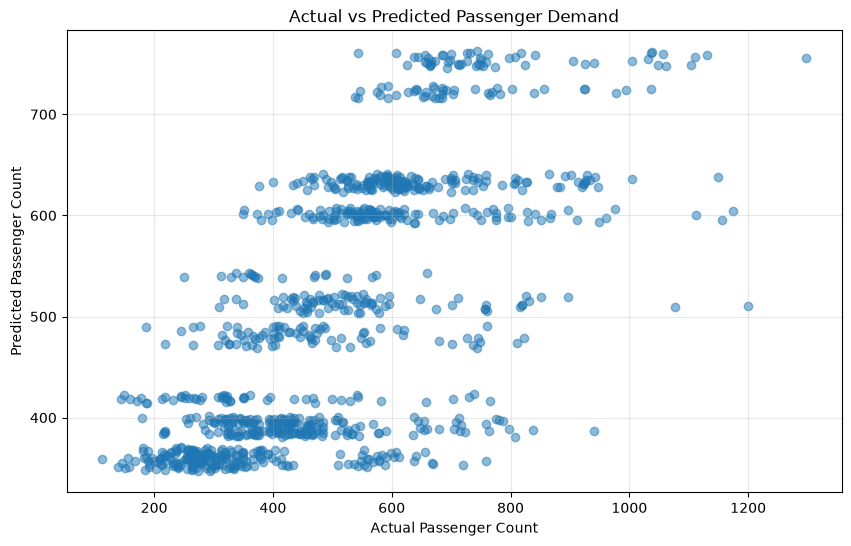


SAMPLE PASSENGER DEMAND PREDICTIONS
 Actual_Passengers  Predicted_Passengers
               454                381.95
               826                520.02
               825                748.69
               260                364.79
               478                395.30
               426                390.87
               574                595.52
               807                637.07
               238                352.54
               261                399.56
               470                414.79
               740                724.57
               568                393.93
               642                724.20
               325                381.68

Model saved successfully!
Path: ../models/demand/passenger_demand.pkl
Predictions saved: ../data/processed/passenger_demand_predictions.csv


🎉 06 PASSENGER DEMAND COMPLETED!


In [1]:
# ============================================================
# RAILPULSE-AI
# 06 - PASSENGER DEMAND PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Starting RailPulse-AI Passenger Demand Prediction...")


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(
    "../data/raw/passenger_data.csv"
)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. CHECK DATA TYPES
# ============================================================

print("\nData information:")
print(df.info())


# ============================================================
# 3. FIND TARGET COLUMN
# ============================================================

possible_targets = [
    "passenger_count",
    "passengers",
    "passenger_demand",
    "demand"
]

target = None

for col in possible_targets:

    if col in df.columns:

        target = col
        break


if target is None:

    raise ValueError(
        "Passenger target column not found. "
        "Check the columns printed above."
    )


print("\nTarget column:", target)


# ============================================================
# 4. CREATE TIME FEATURES
# ============================================================

# If hour column does not exist
if "hour" not in df.columns:

    if "departure_time" in df.columns:

        df["hour"] = pd.to_datetime(
            df["departure_time"],
            errors="coerce"
        ).dt.hour

    elif "time" in df.columns:

        df["hour"] = pd.to_datetime(
            df["time"],
            errors="coerce"
        ).dt.hour

    else:

        # Create a default numeric hour
        df["hour"] = 12


# ============================================================
# 5. CREATE DAY / WEEK FEATURES
# ============================================================

if "day_of_week" not in df.columns:

    if "date" in df.columns:

        df["day_of_week"] = pd.to_datetime(
            df["date"],
            errors="coerce"
        ).dt.dayofweek

    else:

        df["day_of_week"] = 0


# ============================================================
# 6. CREATE WEEKEND FEATURE
# ============================================================

if "is_weekend" not in df.columns:

    df["is_weekend"] = (
        df["day_of_week"] >= 5
    ).astype(int)


# ============================================================
# 7. CREATE PEAK HOUR FEATURE
# ============================================================

if "is_peak_hour" not in df.columns:

    df["is_peak_hour"] = (

        df["hour"].between(7, 10)

        |

        df["hour"].between(17, 21)

    ).astype(int)


# ============================================================
# 8. ENCODE CATEGORICAL COLUMNS
# ============================================================

# Station encoding
if "station" in df.columns:

    df["station_encoded"] = (
        df["station"]
        .astype("category")
        .cat.codes
    )

elif "station_name" in df.columns:

    df["station_encoded"] = (
        df["station_name"]
        .astype("category")
        .cat.codes
    )

else:

    df["station_encoded"] = 0


# Train encoding
if "train_type" in df.columns:

    df["train_type_encoded"] = (
        df["train_type"]
        .astype("category")
        .cat.codes
    )

elif "train_name" in df.columns:

    df["train_type_encoded"] = (
        df["train_name"]
        .astype("category")
        .cat.codes
    )

else:

    df["train_type_encoded"] = 0


# ============================================================
# 9. SELECT FEATURES
# ============================================================

features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "station_encoded",
    "train_type_encoded"
]


# ============================================================
# 10. ADD AVAILABLE NUMERIC FEATURES
# ============================================================

optional_features = [
    "distance_km",
    "temperature",
    "rainfall",
    "capacity",
    "ticket_price",
    "previous_day_passengers",
    "previous_passengers"
]

for col in optional_features:

    if col in df.columns:

        features.append(col)


print("\nFeatures selected:")

for feature in features:

    print("-", feature)


# ============================================================
# 11. CREATE X AND Y
# ============================================================

X = df[features].copy()

y = df[target].copy()


# ============================================================
# 12. HANDLE MISSING VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

y = pd.to_numeric(
    y,
    errors="coerce"
)

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows]

y = y.loc[valid_rows]


print("\nPrepared dataset:")
print("X:", X.shape)
print("y:", y.shape)


# ============================================================
# 13. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)


print("\nTraining data:", X_train.shape)

print(
    "Testing data :",
    X_test.shape
)


# ============================================================
# 14. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)


# ============================================================
# 15. LINEAR REGRESSION METRICS
# ============================================================

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)


print("\n======================================")
print("LINEAR REGRESSION")
print("======================================")

print(
    "MAE :",
    round(linear_mae, 2)
)

print(
    "RMSE:",
    round(linear_rmse, 2)
)

print(
    "R2  :",
    round(linear_r2, 4)
)


# ============================================================
# 16. RANDOM FOREST REGRESSION
# ============================================================

rf_model = RandomForestRegressor(

    n_estimators=200,

    max_depth=15,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)


# ============================================================
# 17. RANDOM FOREST METRICS
# ============================================================

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)


print("\n======================================")
print("RANDOM FOREST REGRESSION")
print("======================================")

print(
    "MAE :",
    round(rf_mae, 2)
)

print(
    "RMSE:",
    round(rf_rmse, 2)
)

print(
    "R2  :",
    round(rf_r2, 4)
)


# ============================================================
# 18. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2
    ]

})


print("\n======================================")
print("PASSENGER DEMAND MODEL COMPARISON")
print("======================================")

print(
    comparison.round(4).to_string(
        index=False
    )
)


# ============================================================
# 19. SELECT BEST MODEL
# ============================================================

if rf_r2 >= linear_r2:

    best_model = rf_model

    best_model_name = "Random Forest"

    best_predictions = rf_pred

else:

    best_model = linear_model

    best_model_name = "Linear Regression"

    best_predictions = linear_pred


print(
    "\nBest Model:",
    best_model_name
)


# ============================================================
# 20. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel(
    "Actual Passenger Count"
)

plt.ylabel(
    "Predicted Passenger Count"
)

plt.title(
    "Actual vs Predicted Passenger Demand"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest":

    importance = pd.DataFrame({

        "Feature": features,

        "Importance":
            best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )


    print("\n======================================")
    print("FEATURE IMPORTANCE")
    print("======================================")

    print(
        importance.round(4).to_string(
            index=False
        )
    )


    plt.figure(
        figsize=(9, 6)
    )

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "Passenger Demand Feature Importance"
    )

    plt.gca().invert_yaxis()

    plt.show()


# ============================================================
# 22. SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual_Passengers":
        y_test.values,

    "Predicted_Passengers":
        best_predictions

})


print("\n======================================")
print("SAMPLE PASSENGER DEMAND PREDICTIONS")
print("======================================")

print(
    results.head(15).round(2).to_string(
        index=False
    )
)


# ============================================================
# 23. SAVE MODEL
# ============================================================

model_folder = "../models/demand"

os.makedirs(
    model_folder,
    exist_ok=True
)

model_path = (
    model_folder +
    "/passenger_demand.pkl"
)

joblib.dump(
    best_model,
    model_path
)


print("\nModel saved successfully!")

print(
    "Path:",
    model_path
)


# ============================================================
# 24. SAVE PREDICTIONS
# ============================================================

prediction_path = (
    "../data/processed/"
    "passenger_demand_predictions.csv"
)

results.to_csv(
    prediction_path,
    index=False
)


print(
    "Predictions saved:",
    prediction_path
)


# ============================================================
# 25. FINAL
# ============================================================

print("\n")
print("======================================")
print("🎉 06 PASSENGER DEMAND COMPLETED!")
print("======================================")